In [16]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, false_discovery_control
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [17]:
BASE_DIR      = Path("/Users/bgadmin/Downloads/multiomics_preproc")
CLUSTER_DIR   = BASE_DIR / "clustering_leiden_A"
CLUSTERS_DIR = CLUSTER_DIR / "clusters_by_group"
MOFA_PATH     = BASE_DIR / "mofa_factors.parquet"
META_PATH     = BASE_DIR / "meta_final.tsv"
GENE_PANEL_PATH = Path("/Users/bgadmin/Downloads/gene_cnv_cancer_panel.tsv")

OUT_DIR = BASE_DIR / "subtyping"
OUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL      = "biosample_id"
CLUSTER_COL = "cluster"
MORPH_COL   = "icdo_morphology_id"
TOPO_COL    = "icdo_topography_id"
SRC_COL     = "source_group"

In [18]:
#Loading

Z_mofa_df = pd.read_parquet(MOFA_PATH)
Z_mofa_df.index = Z_mofa_df.index.astype(str)

meta = pd.read_csv(META_PATH, sep="\t", dtype=str)
meta[ID_COL] = meta[ID_COL].astype(str)

gene_panel = pd.read_csv(
    GENE_PANEL_PATH, sep="\t",
    dtype={"analysis_id": str, "gene_symbol": str}
)
EVENT_COLS = ["dup_frac", "del_frac", "hldup_frac", "hldel_frac"]
gene_panel = gene_panel[["analysis_id", "gene_symbol"] + EVENT_COLS].copy()
gene_panel = gene_panel.dropna(subset=EVENT_COLS, how="all")

print(f"MOFA factors : {Z_mofa_df.shape[0]:,} samples x {Z_mofa_df.shape[1]} factors")
print(f"Metadata     : {meta.shape[0]:,} samples")
print(f"Gene panel   : {gene_panel['analysis_id'].nunique():,} analyses × "
      f"{gene_panel['gene_symbol'].nunique():,} genes")

MOFA factors : 9,592 samples x 20 factors
Metadata     : 9,592 samples
Gene panel   : 239,276 analyses × 1,301 genes


In [19]:
# Load of the clusters and the join of metadata
#Load each parquer file and join it with metadta+MOFA
# On charge chaque fichier parquet et on joint avec meta + MOFA

def load_group_clusters(cancer_group: str) -> pd.DataFrame:
    """Load the clusters of cancer_group from the saved parquet"""
    group_tag = (cancer_group
                 .replace(" ", "_")
                 .replace("(", "").replace(")", "")
                 .replace("/", "_"))
    p = CLUSTERS_DIR / f"{group_tag}_clusters_leiden_cpm.parquet"
    if not p.exists():
        raise FileNotFoundError(f"Clusters not found : {p}")
    C = pd.read_parquet(p).copy()
    C[ID_COL] = C[ID_COL].astype(str)
    return C.drop_duplicates(subset=[ID_COL], keep="first")


def build_group_joined(cancer_group: str) -> pd.DataFrame:
    """
    Join clusters + metadata + MOFA factor for cancer_group.
    """
    C = load_group_clusters(cancer_group)
    M = meta.set_index(ID_COL)
    Z = Z_mofa_df

    out = C.merge(M, on=ID_COL, how="left")
    out = out.merge(Z, left_on=ID_COL, right_index=True, how="left")

    miss_morph = out[MORPH_COL].isna().sum() if MORPH_COL in out.columns else 0
    if miss_morph > 0:
        print(f"[WARN] {cancer_group}: {miss_morph} rows missing {MORPH_COL}")

    return out


# Load all the groups with >= 2 clusters
all_stats_df = pd.read_csv(CLUSTER_DIR / "leiden_manifest_stats.tsv", sep="\t")


# Groups with at leats  2 clusters
groups_with_subtypes = all_stats_df[
    all_stats_df["n_clusters_final_excl_outliers"] >= 2
]["cancer_group"].tolist()

# All groups 
all_groups = all_stats_df["cancer_group"].tolist()

# Build the join tables
group_tables = {}
for cancer_group in all_groups:
    try:
        group_tables[cancer_group] = build_group_joined(cancer_group)
    except FileNotFoundError as e:
        print(f"[SKIP] {e}")

print(f"\nGroups loaded : {len(group_tables)}")
print(f"Groups with >= 2 clusters : {len(groups_with_subtypes)}")
print(groups_with_subtypes)


Groups loaded : 19
Groups with >= 2 clusters : 11
['Brain (C71)', 'Breast (C50)', 'C16', 'Colorectal (C18-C20)', 'Gynecologic (C51-C58)', 'Liver/Biliary (C22-C24)', 'Lung (C30-C39)', 'Lymph nodes (C77)', 'Male genital (C60-C63)', 'Thyroid/Endocrine (C73-C75)', 'Urinary (C64-C68)']


### Validation 
- summarize_sizes → cluster size distribution
- weighted_topfrac → morphological consistency per cluster
- per_cluster_top_labels → top morphologies per cluster
- outlier_profile → outlier profile

In [20]:
OUTLIER = -1

def summarize_sizes(df: pd.DataFrame, outlier_label: int = OUTLIER) -> dict:
    """Cluster size distribution """
    vc      = df[CLUSTER_COL].value_counts(dropna=False)
    n_total = int(len(df))
    n_out   = int(vc.get(outlier_label, 0))
    vc2     = vc.drop(index=[outlier_label], errors="ignore")

    if len(vc2) == 0:
        return {
            "n_total": n_total, "n_outliers": n_out,
            "frac_outliers": n_out / max(1, n_total),
            "n_clusters_excl_outliers": 0,
            "min_cluster": np.nan, "median_cluster": np.nan,
            "max_cluster": np.nan, "max_cluster_frac": np.nan,
        }

    sizes = vc2.values.astype(int)
    return {
        "n_total":                    n_total,
        "n_outliers":                 n_out,
        "frac_outliers":              n_out / max(1, n_total),
        "n_clusters_excl_outliers":   int(len(vc2)),
        "min_cluster":                int(sizes.min()),
        "median_cluster":             float(np.median(sizes)),
        "max_cluster":                int(sizes.max()),
        "max_cluster_frac":           float(sizes.max() / max(1, vc2.sum())),
    }


def topfrac(s: pd.Series) -> float:
    """Fraction of the most frequent label in a series."""
    s = s.dropna()
    if len(s) == 0:
        return np.nan
    vc = s.value_counts()
    return float(vc.iloc[0] / vc.sum())


def weighted_topfrac_by_cluster(df: pd.DataFrame, label_col: str,
                                  outlier_label: int = OUTLIER) -> float:
    """
    Morphological consistency weighted by cluster.
    For each cluster, calculate the fraction of the dominant label,
    then take a weighted average based on the cluster size.
    A value close to 1 indicates that the clusters are morphologically pure.
    """
    if label_col not in df.columns:
        return np.nan
    d = df[df[CLUSTER_COL] != outlier_label].copy()
    if len(d) == 0:
        return np.nan
    parts = []
    for c, g in d.groupby(CLUSTER_COL):
        tf = topfrac(g[label_col])
        w  = len(g)
        if np.isfinite(tf):
            parts.append((tf, w))
    if not parts:
        return np.nan
    num = sum(tf * w for tf, w in parts)
    den = sum(w for _, w in parts)
    return float(num / max(1, den))


def per_cluster_top_labels(df: pd.DataFrame, label_col: str,
                            k: int = 3) -> pd.DataFrame:
    """Top k labels per cluster."""
    rows = []
    if label_col not in df.columns:
        return pd.DataFrame()
    
    for c, g in df.groupby(CLUSTER_COL):
        vc  = g[label_col].astype(str).value_counts(dropna=False).head(k)
        top = "; ".join([f"{idx}:{int(cnt)}" for idx, cnt in vc.items()])
        rows.append({
            "cluster":              int(c),
            "n":                    int(len(g)),
            f"{label_col}_top{k}":  top,
        })
    
    # si la liste rows est vide, on retourne un DataFrame vide typé
    if not rows:
        return pd.DataFrame(columns=["cluster", "n", f"{label_col}_top{k}"])
        
    return pd.DataFrame(rows).sort_values("n", ascending=False)


def outlier_profile(df: pd.DataFrame, k: int = 5) -> dict:
    """Outliers profils """
    o = df[df[CLUSTER_COL] == OUTLIER].copy()
    if len(o) == 0:
        return {"n_outliers": 0}

    def topk(col):
        if col not in o.columns:
            return ""
        vc = o[col].astype(str).value_counts().head(k)
        return "; ".join([f"{idx}:{int(cnt)}" for idx, cnt in vc.items()])

    return {
        "n_outliers": int(len(o)),
        "morph_top":  topk(MORPH_COL),
        "topo_top":   topk(TOPO_COL),
        "src_top":    topk(SRC_COL) if SRC_COL in o.columns else "",
    }

In [21]:
# Validation metric calculation 
qc_rows         = []
cluster_summaries = []
outlier_rows    = []

for cancer_group, df in group_tables.items():

    # Size of the clusters
    sz = summarize_sizes(df)
    sz["cancer_group"] = cancer_group
    qc_rows.append({
        "cancer_group":             cancer_group,
        "morph_topfrac_weighted":   weighted_topfrac_by_cluster(df, MORPH_COL),
        "topo_topfrac_weighted":    weighted_topfrac_by_cluster(df, TOPO_COL),
        "n_missing_morph":          int(df[MORPH_COL].isna().sum())
                                    if MORPH_COL in df.columns else np.nan,
        **sz,
    })

    # Top labels per cluster
    csum = per_cluster_top_labels(
        df[df[CLUSTER_COL] != OUTLIER], MORPH_COL, k=3
    )
    if len(csum):
        csum.insert(0, "cancer_group", cancer_group)
        cluster_summaries.append(csum)

    # Profil outliers
    prof = outlier_profile(df, k=5)
    prof["cancer_group"] = cancer_group
    outlier_rows.append(prof)

qc_df = pd.DataFrame(qc_rows).sort_values(
    "morph_topfrac_weighted", ascending=False
).reset_index(drop=True)

cluster_summary_df = pd.concat(cluster_summaries, ignore_index=True) \
    if cluster_summaries else pd.DataFrame()

outlier_df = pd.DataFrame(outlier_rows).sort_values(
    "n_outliers", ascending=False
)


print(qc_df[[
    "cancer_group", "n_total", "n_clusters_excl_outliers",
    "n_outliers", "frac_outliers",
    "morph_topfrac_weighted", "topo_topfrac_weighted"
]].to_string(index=False))

print("\n Top morphology per cluster")
print(cluster_summary_df.to_string(index=False))

print("\nOutliers Profil ")
print(outlier_df[outlier_df["n_outliers"] > 0].to_string(index=False))

                         cancer_group  n_total  n_clusters_excl_outliers  n_outliers  frac_outliers  morph_topfrac_weighted  topo_topfrac_weighted
                    Blood/Lymph (C42)      107                         1          47       0.439252                1.000000               1.000000
              Liver/Biliary (C22-C24)      398                         2           0       0.000000                0.866834               0.914573
                    Lymph nodes (C77)      237                         2           0       0.000000                0.852321               0.405063
                Head & Neck (C00_C14)      379                         1           3       0.007916                0.837766               0.327128
                 Colorectal (C18-C20)      565                         2           0       0.000000                0.837168               0.208850
                                  C25      165                         1          43       0.260606                0.8

### Visualization :
Scatter n_cluster vs morpholy coherence 

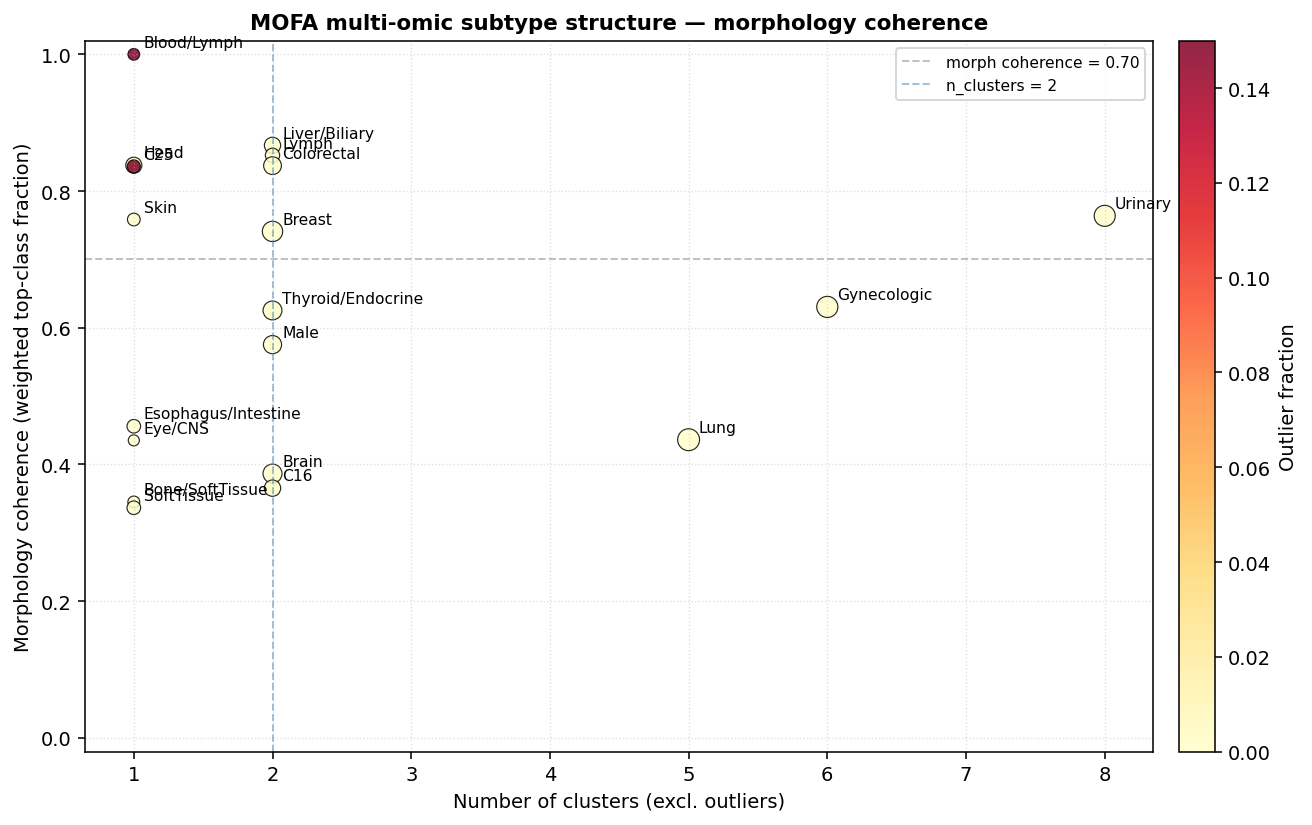

In [22]:
# x = number of clusters, y = morphology coherence
# points sizes = number of samples, coulorr =  outliers fraction

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

df_plot = qc_df[qc_df["n_clusters_excl_outliers"] >= 1].copy()
df_plot["n_clusters_excl_outliers"] = df_plot["n_clusters_excl_outliers"].astype(float)
df_plot["morph_topfrac_weighted"]   = df_plot["morph_topfrac_weighted"].astype(float)
df_plot["frac_outliers"]            = df_plot["frac_outliers"].astype(float)
df_plot["n_total"]                  = df_plot["n_total"].astype(float)

x     = df_plot["n_clusters_excl_outliers"].to_numpy()
y     = df_plot["morph_topfrac_weighted"].to_numpy()
c     = df_plot["frac_outliers"].to_numpy()
sizes = 70.0 * np.sqrt(df_plot["n_total"].to_numpy() /
                        np.nanmedian(df_plot["n_total"].to_numpy()))

fig, ax = plt.subplots(figsize=(10, 6), dpi=140)
sc = ax.scatter(x, y, s=sizes, c=c, alpha=0.85,
                linewidths=0.6, edgecolors="black",
                cmap="YlOrRd", vmin=0, vmax=0.15)

# Lignes de référence
ax.axhline(0.70, linestyle="--", linewidth=1.0, alpha=0.5,
           color="grey", label="morph coherence = 0.70")
ax.axvline(2,    linestyle="--", linewidth=1.0, alpha=0.5,
           color="steelblue", label="n_clusters = 2")

# Annotations
for _, row in df_plot.iterrows():
    ax.annotate(
        row["cancer_group"].split(" ")[0],
        (row["n_clusters_excl_outliers"], row["morph_topfrac_weighted"]),
        xytext=(5, 4), textcoords="offset points", fontsize=8
    )

cb = fig.colorbar(sc, ax=ax, pad=0.02)
cb.set_label("Outlier fraction")

ax.set_xlabel("Number of clusters (excl. outliers)")
ax.set_ylabel("Morphology coherence (weighted top-class fraction)")
ax.set_title("MOFA multi-omic subtype structure — morphology coherence",
             fontsize=11, fontweight="bold")
ax.set_ylim(-0.02, 1.02)
ax.legend(fontsize=8)
ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.4)
plt.tight_layout()
plt.show()

### MOFA Signatures by Cluster 
For each cancer_group with >= 2 clusters:
- Which MOFA factors best distinguish the clusters?

- Mann-Whitney U test on MOFA factors (cluster vs. remainder)
-  Which omics dominates these factors?

In [23]:
from scipy.stats import mannwhitneyu

# Load r2_df (explaiend variance expliquée per factor and omic)
# to determine which omics dominates each factor
r2_df = pd.read_csv(BASE_DIR / "mofa_r2_per_factor.tsv", sep="\t", index_col=0)

factor_cols = [f"Factor{i+1}" for i in range(20)]

mofa_sig_rows = []

for cancer_group in groups_with_subtypes:
    df = group_tables[cancer_group]
    df_in = df[df[CLUSTER_COL] != OUTLIER].copy()

    clusters = sorted(df_in[CLUSTER_COL].unique())
    if len(clusters) < 2:
        continue

    print(f"\n{'='*50}")
    print(f"{cancer_group} — {len(clusters)} clusters")

    for cl in clusters:
        grp_cl   = df_in[df_in[CLUSTER_COL] == cl]
        grp_rest = df_in[df_in[CLUSTER_COL] != cl]

        n_cl   = len(grp_cl)
        n_rest = len(grp_rest)

        for fac in factor_cols:
            if fac not in df_in.columns:
                continue

            x = grp_cl[fac].dropna().to_numpy(dtype=float)
            y = grp_rest[fac].dropna().to_numpy(dtype=float)

            if len(x) < 2 or len(y) < 2:
                continue

            try:
                u_res = mannwhitneyu(x, y, alternative="two-sided")
                p     = float(u_res.pvalue)
                U     = float(u_res.statistic)
                auc   = U / (len(x) * len(y))
            except Exception:
                p, auc = np.nan, np.nan

            delta = float(np.mean(x) - np.mean(y))

            # Omique dominante de ce facteur
            if fac in r2_df.index:
                dominant_omic = r2_df.loc[fac].idxmax()
            else:
                dominant_omic = "Unknown"

            mofa_sig_rows.append({
                "cancer_group":   cancer_group,
                "cluster":        int(cl),
                "factor":         fac,
                "dominant_omic":  dominant_omic,
                "delta":          delta,
                "auc":            auc,
                "p_value":        p,
                "n_cluster":      n_cl,
                "n_rest":         n_rest,
            })

mofa_sig_df = pd.DataFrame(mofa_sig_rows)

# BH-FDR correction per cancer_group × cluster
from scipy.stats import false_discovery_control

mofa_sig_df["q_value"] = np.nan
for (cg, cl), sub_idx in mofa_sig_df.groupby(
    ["cancer_group", "cluster"]
).groups.items():
    p    = mofa_sig_df.loc[sub_idx, "p_value"].to_numpy(dtype=float)
    msk  = np.isfinite(p)
    q    = np.full_like(p, np.nan, dtype=float)
    if msk.any():
        q[msk] = false_discovery_control(p[msk], method="bh")
    mofa_sig_df.loc[sub_idx, "q_value"] = q

# Top significant factors by cluster
mofa_sig_sig = mofa_sig_df[
    (mofa_sig_df["q_value"] <= 0.05) &
    (np.abs(mofa_sig_df["auc"] - 0.5) >= 0.1)  # AUC loin de 0.5
].copy()

mofa_sig_sig["score"] = np.sign(mofa_sig_sig["delta"]) * \
    (-np.log10(mofa_sig_sig["q_value"].clip(1e-300, 1)))

print("\n Top MOFA discriminating factors by cluster ")
for cancer_group in groups_with_subtypes:
    sub = mofa_sig_sig[mofa_sig_sig["cancer_group"] == cancer_group]
    if sub.empty:
        continue
    print(f"\n{cancer_group} :")
    for cl, grp in sub.groupby("cluster"):
        top = grp.reindex(
            grp["score"].abs().sort_values(ascending=False).index
        ).head(5)
        print(f"  Cluster {cl} :")
        for _, r in top.iterrows():
            direction = "↑" if r["delta"] > 0 else "↓"
            print(f"    {r['factor']} ({r['dominant_omic']}) "
                  f"{direction}  AUC={r['auc']:.3f}  q={r['q_value']:.2e}")


Brain (C71) — 2 clusters

Breast (C50) — 2 clusters

C16 — 2 clusters

Colorectal (C18-C20) — 2 clusters

Gynecologic (C51-C58) — 6 clusters

Liver/Biliary (C22-C24) — 2 clusters

Lung (C30-C39) — 5 clusters

Lymph nodes (C77) — 2 clusters

Male genital (C60-C63) — 2 clusters

Thyroid/Endocrine (C73-C75) — 2 clusters

Urinary (C64-C68) — 8 clusters

 Top MOFA discriminating factors by cluster 

Brain (C71) :
  Cluster 0 :
    Factor14 (CNV) ↑  AUC=0.995  q=1.34e-84
    Factor11 (Meth) ↑  AUC=0.984  q=5.30e-81
    Factor8 (Meth) ↓  AUC=0.018  q=8.21e-81
    Factor13 (Meth) ↓  AUC=0.026  q=3.33e-78
    Factor20 (CNV) ↓  AUC=0.044  q=1.14e-72
  Cluster 1 :
    Factor14 (CNV) ↓  AUC=0.005  q=1.34e-84
    Factor11 (Meth) ↓  AUC=0.016  q=5.30e-81
    Factor8 (Meth) ↑  AUC=0.982  q=8.21e-81
    Factor13 (Meth) ↑  AUC=0.974  q=3.33e-78
    Factor20 (CNV) ↑  AUC=0.956  q=1.14e-72

Breast (C50) :
  Cluster 0 :
    Factor3 (Meth) ↑  AUC=1.000  q=6.26e-134
    Factor1 (RNA) ↑  AUC=0.997  q=5.49e-

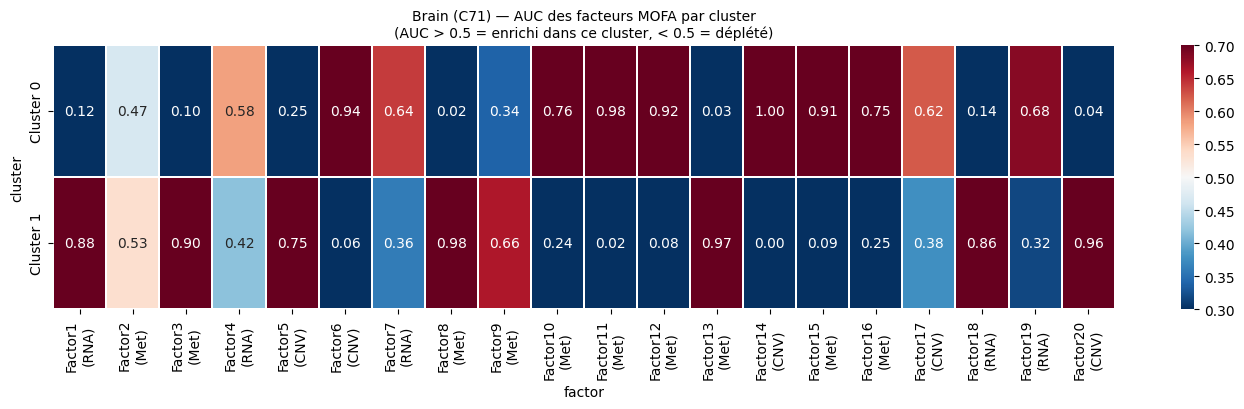

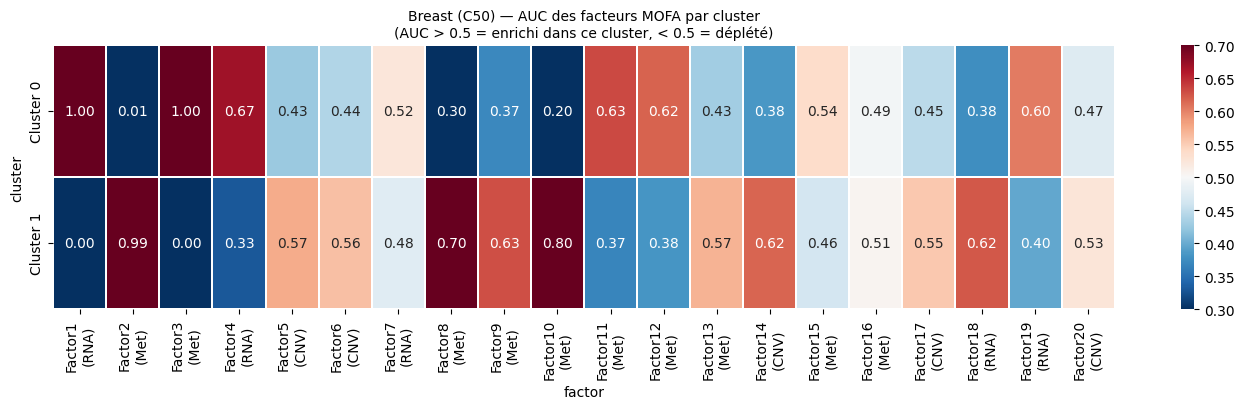

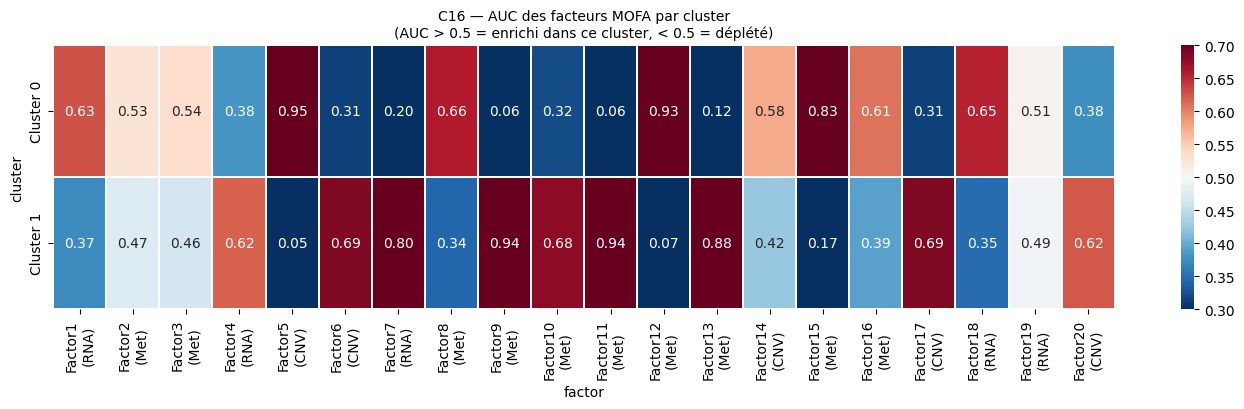

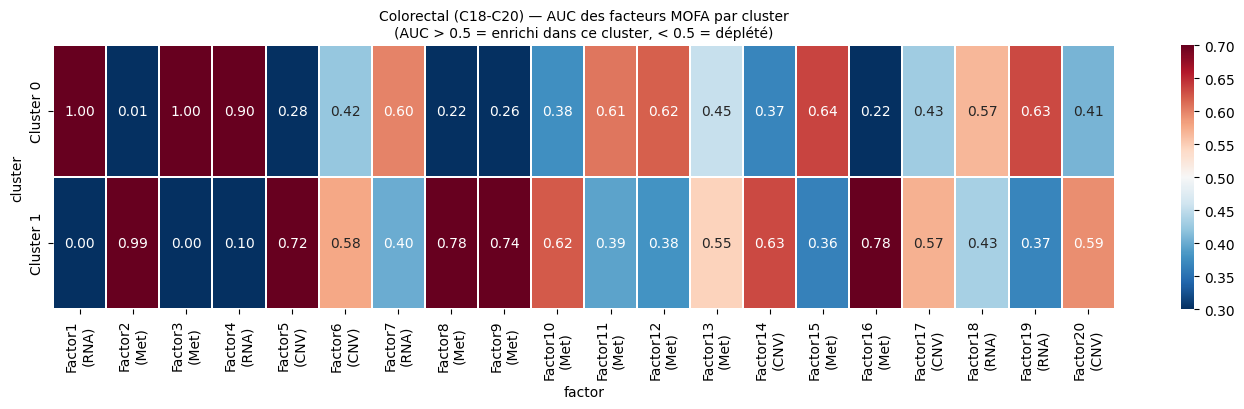

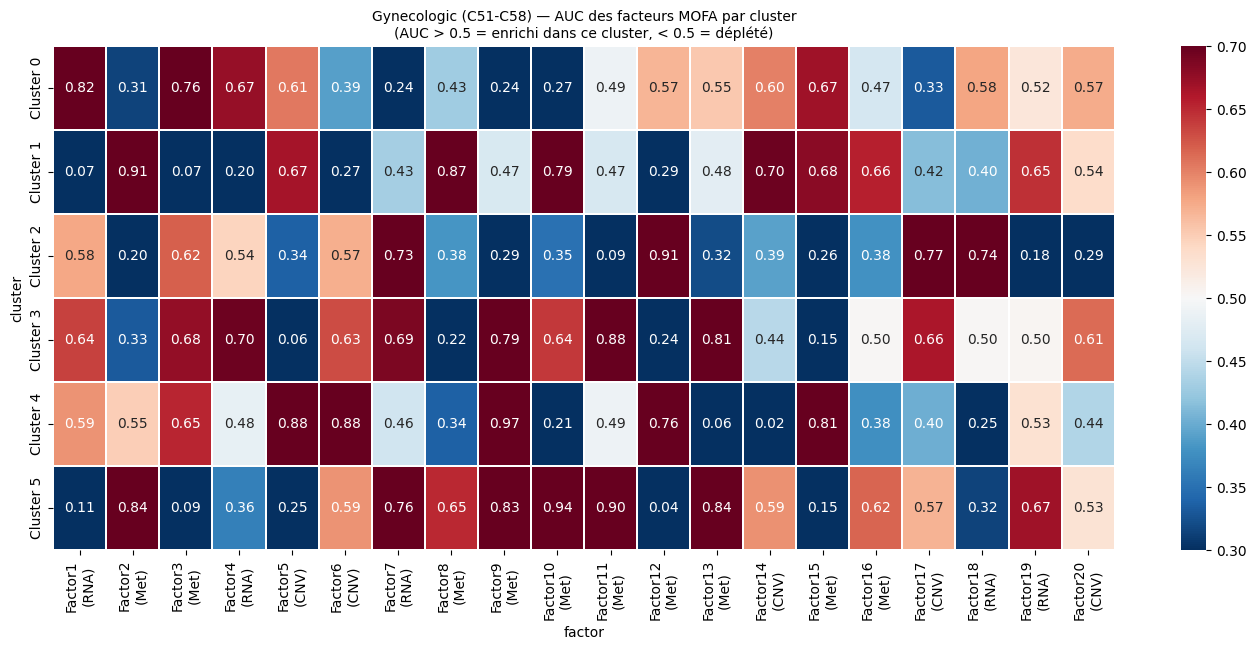

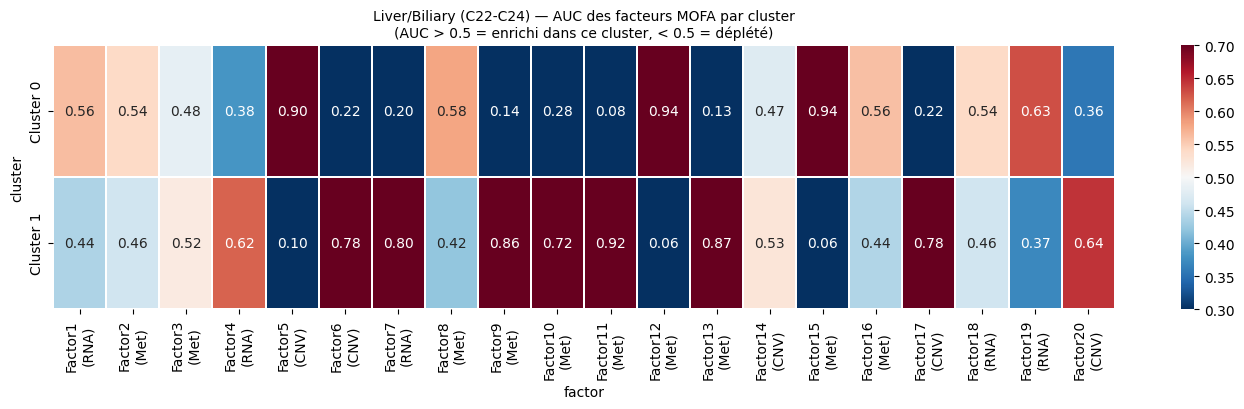

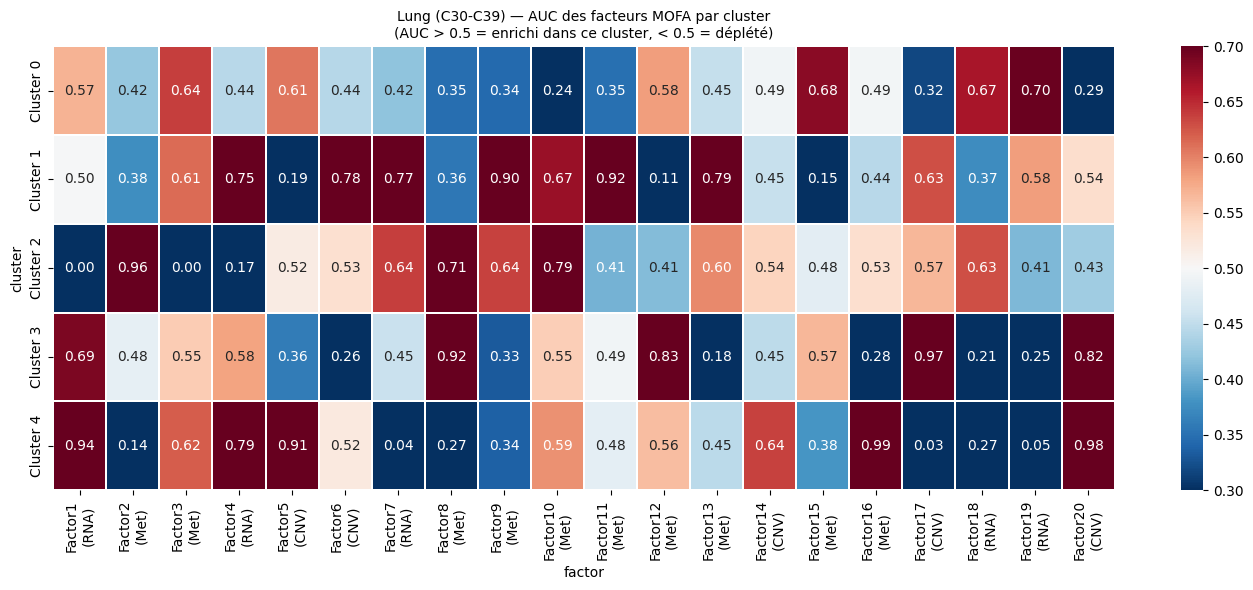

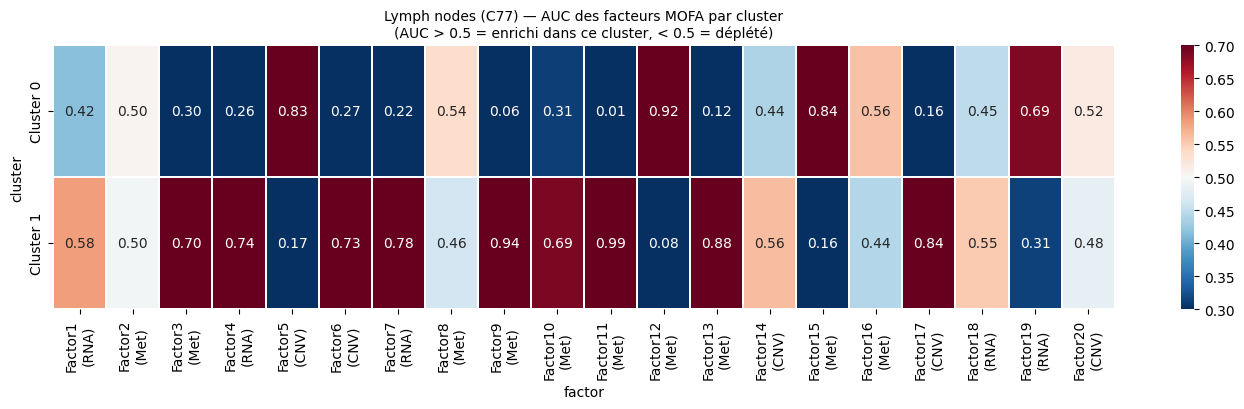

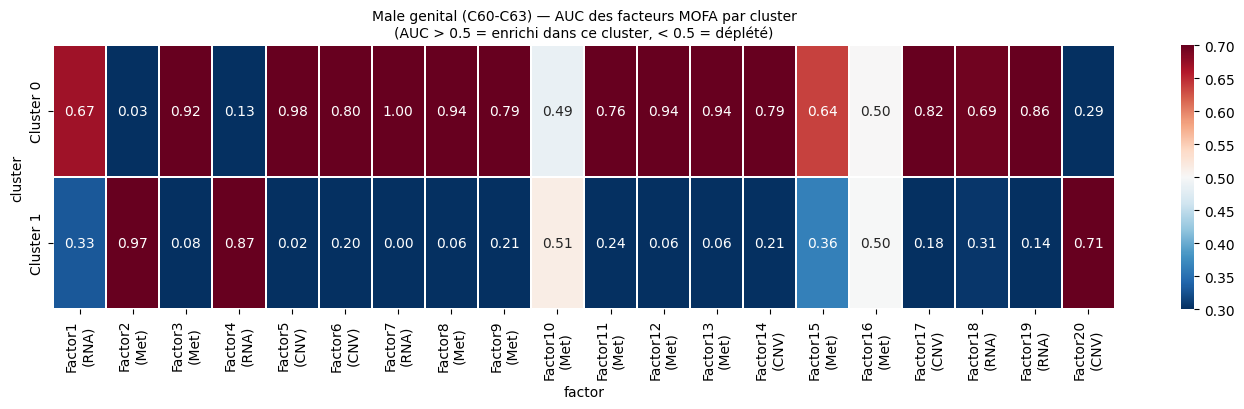

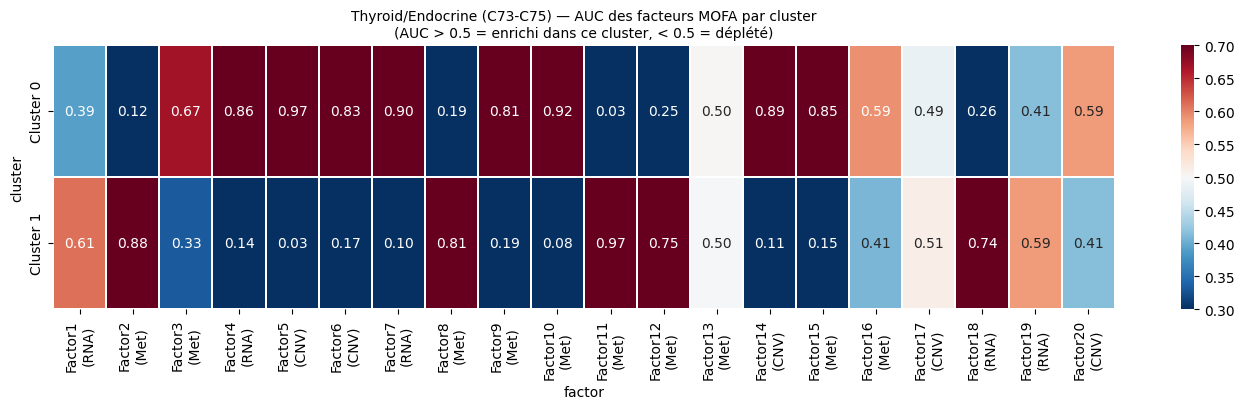

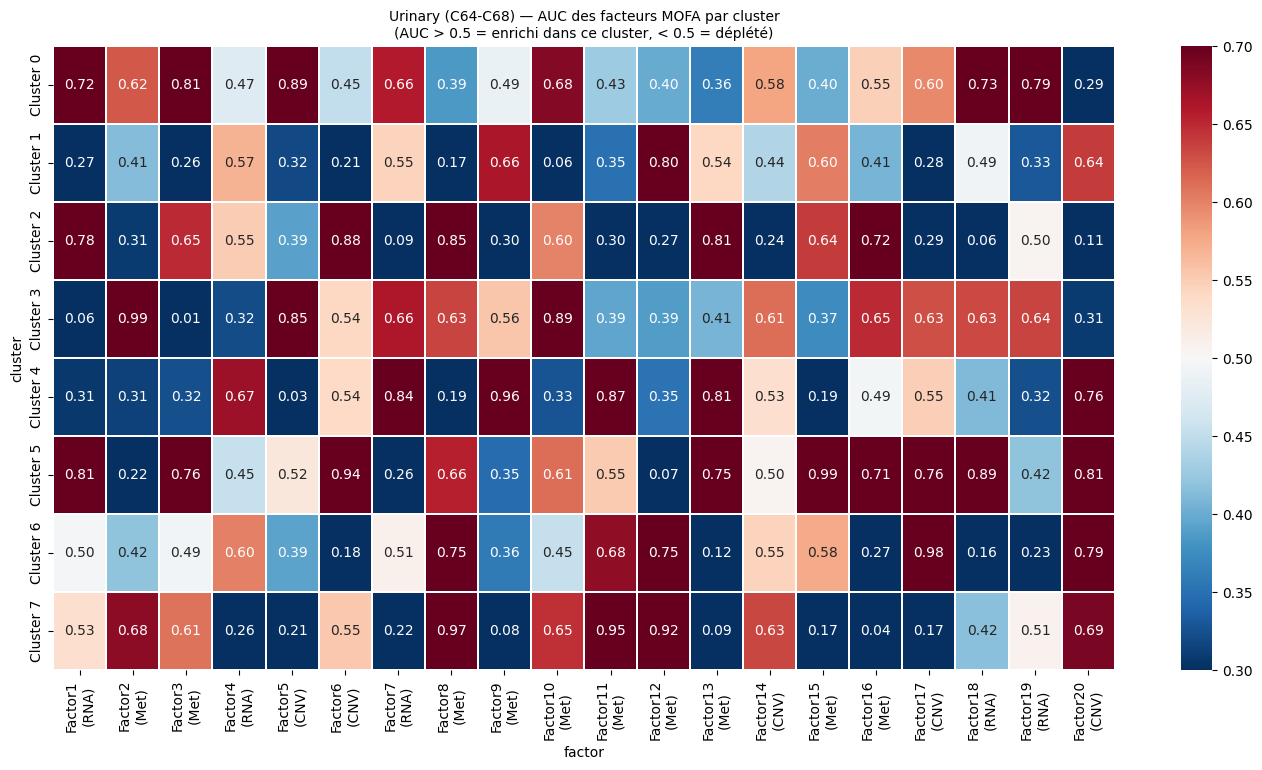

In [24]:
# heatmap des AUC MOFA par cluster

import seaborn as sns

for cancer_group in groups_with_subtypes:
    sub = mofa_sig_df[mofa_sig_df["cancer_group"] == cancer_group].copy()
    if sub.empty:
        continue

    pivot = sub.pivot_table(
        index="cluster", columns="factor", values="auc"
    )
    # Réordonner les colonnes
    factor_order = [f"Factor{i+1}" for i in range(20)
                    if f"Factor{i+1}" in pivot.columns]
    pivot = pivot[factor_order]

    # Ajouter l'omique dominante en annotation de colonne
    omic_labels = {
        fac: mofa_sig_df[mofa_sig_df["factor"] == fac]["dominant_omic"].iloc[0]
        if not mofa_sig_df[mofa_sig_df["factor"] == fac].empty else ""
        for fac in factor_order
    }
    col_labels = [f"{f}\n({omic_labels[f][:3]})" for f in factor_order]

    plt.figure(figsize=(14, 3 + len(pivot) * 0.6))
    sns.heatmap(
        pivot,
        annot=True, fmt=".2f",
        cmap="RdBu_r", center=0.5,
        vmin=0.3, vmax=0.7,
        xticklabels=col_labels,
        yticklabels=[f"Cluster {c}" for c in pivot.index],
        linewidths=0.3,
    )
    plt.title(f"{cancer_group} — AUC des facteurs MOFA par cluster\n"
              f"(AUC > 0.5 = enrichi dans ce cluster, < 0.5 = déplété)",
              fontsize=10)
    plt.tight_layout()
    plt.show()

In [25]:
# ── Sauvegarde des résultats du notebook de subtyping ─────────────

# 1. QC dashboard (morph_topfrac_weighted, taille clusters, outliers)
qc_df.to_csv(OUT_DIR / "subtyping_qc.tsv", sep="\t", index=False)
print(f"[saved] subtyping_qc.tsv")

# 2. Top morphologies par cluster
cluster_summary_df.to_csv(
    OUT_DIR / "cluster_top_morphologies.tsv", sep="\t", index=False
)
print(f"[saved] cluster_top_morphologies.tsv")

# 3. Profil des outliers
outlier_df.to_csv(OUT_DIR / "outlier_profiles.tsv", sep="\t", index=False)
print(f"[saved] outlier_profiles.tsv")

# 4. Toutes les signatures MOFA (toutes les lignes)
mofa_sig_df.to_csv(OUT_DIR / "mofa_signatures_all.tsv", sep="\t", index=False)
print(f"[saved] mofa_signatures_all.tsv")

# 5. Signatures MOFA significatives seulement (q <= 0.05, AUC loin de 0.5)
mofa_sig_sig.to_csv(OUT_DIR / "mofa_signatures.tsv", sep="\t", index=False)
print(f"[saved] mofa_signatures.tsv")

print(f"\nTous les fichiers sauvegardés dans : {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    if f.suffix in [".tsv", ".parquet"]:
        print(f"  {f.name}")

[saved] subtyping_qc.tsv
[saved] cluster_top_morphologies.tsv
[saved] outlier_profiles.tsv
[saved] mofa_signatures_all.tsv
[saved] mofa_signatures.tsv

Tous les fichiers sauvegardés dans : /Users/bgadmin/Downloads/multiomics_preproc/subtyping
  cluster_top_morphologies.tsv
  mofa_signatures.tsv
  mofa_signatures_all.tsv
  outlier_profiles.tsv
  subtyping_qc.tsv


### Predictive validation on discriminant MOFA signatures ─
 Purpose : verify that the MOFA discriminant signatures are biologically robust and generalizable.
 Classifier trained only on the TOP discriminant factors (those identified as significant in the MWU test)
- proves that the biological signatures are robust
- stronger validation : "even with less information,
- subtypes remain separable"

In [26]:
# Charger les signatures MOFA significatives
mofa_sig_path = BASE_DIR / "subtyping" / "mofa_signatures.tsv"
sig_sub = mofa_sig_sig[
    mofa_sig_sig["cancer_group"] == cancer_group
].copy()
print(f"Signatures MOFA loaded : {mofa_sig_df.shape}")
print(f"Cancer groups : {mofa_sig_df['cancer_group'].nunique()}")

Signatures MOFA loaded : (700, 10)
Cancer groups : 11


In [27]:
def make_clf(random_state=0):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(
            l1_ratio=0,
            solver="saga",
            max_iter=5000,
            C=0.5,
            random_state=random_state,
        ))
    ])

In [28]:
sig_pred_rows = []

for cancer_group, df in group_tables.items():
    df_in = df[df[CLUSTER_COL] != OUTLIER].copy()
    if df_in[CLUSTER_COL].nunique() < 2:
        continue

    # Récupérer les facteurs discriminants pour ce groupe
    sig_sub = mofa_sig_df[
        mofa_sig_df["cancer_group"] == cancer_group
    ].copy()

    if sig_sub.empty:
        continue

    # Top facteurs discriminants — ceux avec AUC le plus loin de 0.5
    sig_sub["auc_dev"] = np.abs(sig_sub["auc"] - 0.5)
    top_factors = (
        sig_sub
        .sort_values("auc_dev", ascending=False)
        .drop_duplicates("factor")
        .head(10)["factor"]
        .tolist()
    )

    # Garder seulement les facteurs disponibles dans df_in
    top_factors = [f for f in top_factors if f in df_in.columns]

    if len(top_factors) < 2:
        print(f"[SKIP] {cancer_group} — moins de 2 facteurs discriminants")
        continue

    X_sig = df_in[top_factors].to_numpy(dtype=float)
    y_sig = df_in[CLUSTER_COL].astype(int).to_numpy()

    if len(X_sig) < 50:
        continue

    # Cross-validation 5-fold sur les facteurs discriminants seulement
    skf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
    clf_sig  = make_clf()

    bal_accs_sig = cross_val_score(
        clf_sig, X_sig, y_sig, cv=skf,
        scoring="balanced_accuracy"
    )
    f1s_sig = cross_val_score(
        clf_sig, X_sig, y_sig, cv=skf,
        scoring="f1_macro"
    )


    sig_pred_rows.append({
    "cancer_group":     cancer_group,
    "n_samples":        int(len(X_sig)),
    "n_clusters":       int(df_in[CLUSTER_COL].nunique()),
    "n_factors_used":   int(len(top_factors)),
    "factors_used":     ", ".join(top_factors),
    "dominant_omics":   ", ".join(
        sig_sub[sig_sub["factor"].isin(top_factors)]
        ["dominant_omic"].value_counts().index.tolist()[:3]
    ),
    "bal_acc_sig_mean": float(np.mean(bal_accs_sig)),
    "bal_acc_sig_std":  float(np.std(bal_accs_sig)),
    "f1_sig_mean":      float(np.mean(f1s_sig)),
})

sig_pred_df = pd.DataFrame(sig_pred_rows).sort_values(
    "bal_acc_sig_mean", ascending=False
)

print("\n=== Predictive validation on discriminating MOFA signatures ===\n")
print(sig_pred_df[[
    "cancer_group", "n_factors_used", "dominant_omics",
    "bal_acc_sig_mean", "bal_acc_sig_std",
    "f1_sig_mean"
]].to_string(index=False))


=== Predictive validation on discriminating MOFA signatures ===

               cancer_group  n_factors_used dominant_omics  bal_acc_sig_mean  bal_acc_sig_std  f1_sig_mean
               Breast (C50)              10      Meth, RNA          1.000000         0.000000     1.000000
       Colorectal (C18-C20)              10 Meth, RNA, CNV          1.000000         0.000000     1.000000
    Liver/Biliary (C22-C24)              10 Meth, CNV, RNA          0.998148         0.003704     0.997179
                Brain (C71)              10 Meth, CNV, RNA          0.995381         0.007247     0.994368
     Male genital (C60-C63)              10 Meth, RNA, CNV          0.990256         0.010157     0.990176
                        C16              10 Meth, CNV, RNA          0.990000         0.020000     0.994038
          Lymph nodes (C77)              10 Meth, CNV, RNA          0.987500         0.011693     0.980898
Thyroid/Endocrine (C73-C75)              10 Meth, CNV, RNA          0.980556  

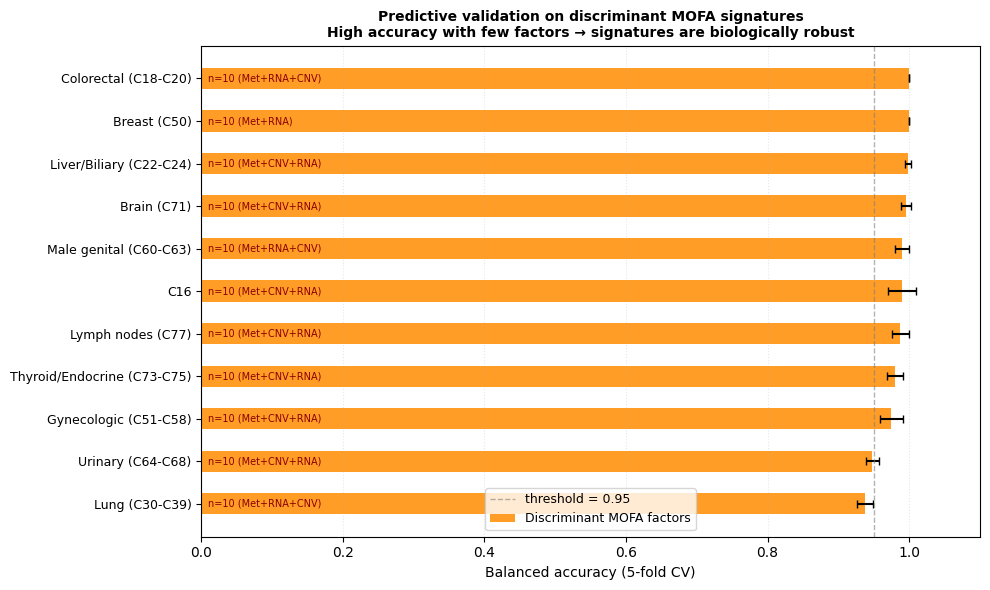

In [29]:
# ── Visualization : discriminant factors predictability ───────────
fig, ax = plt.subplots(figsize=(10, 6))

sig_sorted = sig_pred_df.sort_values("bal_acc_sig_mean", ascending=True)
x     = np.arange(len(sig_sorted))
width = 0.5

bars = ax.barh(
    x,
    sig_sorted["bal_acc_sig_mean"],
    width,
    label="Discriminant MOFA factors",
    color="darkorange", alpha=0.85,
    xerr=sig_sorted["bal_acc_sig_std"],
    capsize=3
)

# Annoter chaque barre — la boucle for est indispensable
for i, (_, row) in enumerate(sig_sorted.iterrows()):
    omics_abbrev = "+".join([
        o.strip()[:3]
        for o in row["dominant_omics"].split(",")
    ])
    ax.text(
        0.01, i,
        f"n={int(row['n_factors_used'])} ({omics_abbrev})",
        va="center", fontsize=7, color="darkred"
    )

ax.set_yticks(x)
ax.set_yticklabels(sig_sorted["cancer_group"], fontsize=9)
ax.axvline(
    0.95, linestyle="--", color="grey",
    linewidth=1, alpha=0.6, label="threshold = 0.95"
)
ax.set_xlabel("Balanced accuracy (5-fold CV)")
ax.set_title(
    "Predictive validation on discriminant MOFA signatures\n"
    "High accuracy with few factors → signatures are biologically robust",
    fontsize=10, fontweight="bold"
)
ax.legend(fontsize=9)
ax.set_xlim(0, 1.1)
ax.grid(axis="x", linestyle=":", alpha=0.3)
plt.tight_layout()
plt.show()

In [30]:
# ── Save ──────────────────────────────────────────────────────────
sig_pred_df.to_csv(
    OUT_DIR / "signature_predictability.tsv",
    sep="\t", index=False
)
print(f"[saved] signature_predictability.tsv")

[saved] signature_predictability.tsv
